# Probabilistic Temporal Transformer Forecasting

This notebook demonstrates how to use the temporal transformer with a mixture density output head for probabilistic forecasting. It compares a deterministic transformer against an MDN transformer on the same heteroscedastic synthetic forecasting task.

## What This Notebook Covers

1. Build a fixed-window forecasting dataset with changing noise levels.
2. Train a deterministic `TemporalTransformerNetwork`.
3. Train a probabilistic `TemporalTransformerNetwork` using `num_mixtures > 0`.
4. Use `make_predictions` to recover predictive means and standard deviations.
5. Compare RMSE and calibration-oriented metrics such as CRPS, PICP, MPIW, and NLL.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, TensorDataset

from ptmelt.models import TemporalTransformerNetwork
from ptmelt.utils.evaluation import make_predictions
from ptmelt.utils.preprocessing import get_normalizers
from ptmelt.utils.statistics import (
    compute_crps,
    compute_mpiw,
    compute_picp,
    compute_rmse,
    compute_rsquared,
    pdf_based_nll,
)

np.random.seed(7)
torch.manual_seed(7)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## Build a Forecasting Dataset with Heteroscedastic Noise

The target contains a predictable mean structure, but the observation noise changes over time. This is a good setting for testing whether the probabilistic transformer learns useful forecast spread rather than only point accuracy.

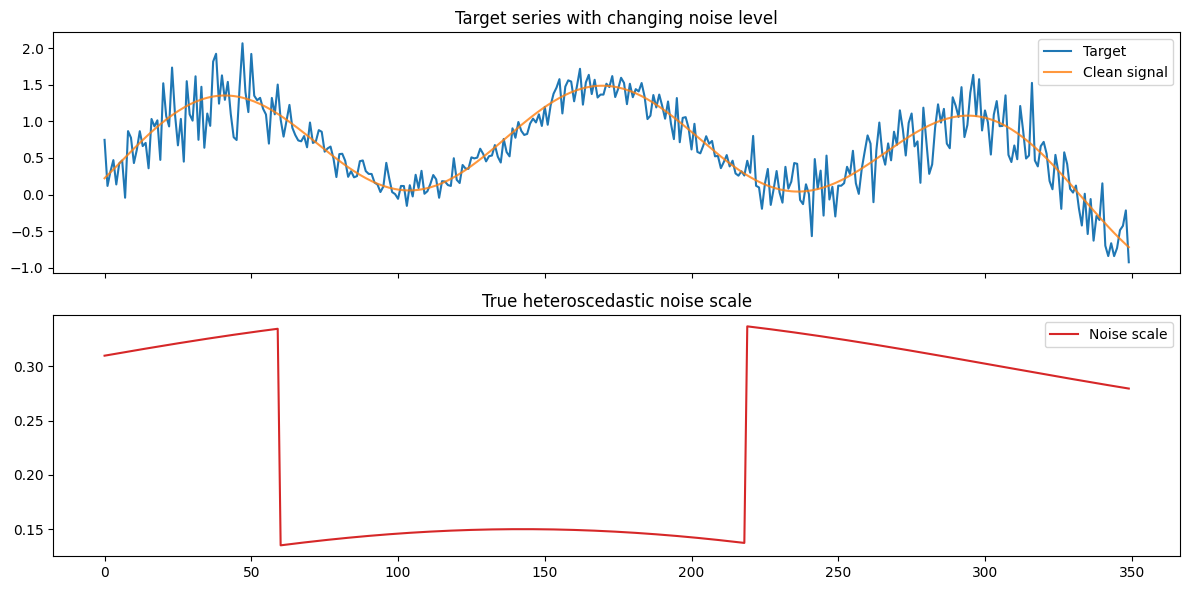

In [2]:
n_steps = 1600
lookback = 36
batch_size = 64

t = np.linspace(0.0, 70.0, n_steps, dtype=np.float32)
slow_cycle = np.sin(0.22 * t + 0.2)
fast_cycle = 0.7 * np.sin(1.1 * t - 0.3)
driver = np.cos(0.45 * t + 0.4)
trend = 0.0035 * t
noise_scale = 0.05 + 0.20 * (driver > 0).astype(np.float32) + 0.05 * (slow_cycle + 1.0)
noise = noise_scale * np.random.randn(n_steps).astype(np.float32)

clean_signal = slow_cycle + fast_cycle + 0.25 * driver + trend
target = clean_signal + noise
features = np.column_stack([target, slow_cycle, driver, noise_scale]).astype(np.float32)
target = target.reshape(-1, 1).astype(np.float32)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(target[:350], label="Target")
axes[0].plot(clean_signal[:350], label="Clean signal", alpha=0.8)
axes[0].set_title("Target series with changing noise level")
axes[0].legend()
axes[1].plot(noise_scale[:350], color="tab:red", label="Noise scale")
axes[1].set_title("True heteroscedastic noise scale")
axes[1].legend()
plt.tight_layout()
plt.show()

In [3]:
def make_windows(feature_array, target_array, lookback):
    x_windows = []
    y_windows = []
    for end_idx in range(lookback, len(feature_array)):
        start_idx = end_idx - lookback
        x_windows.append(feature_array[start_idx:end_idx])
        y_windows.append(target_array[end_idx])
    return np.asarray(x_windows, dtype=np.float32), np.asarray(
        y_windows, dtype=np.float32
    )


train_end = int(0.70 * n_steps)
val_end = int(0.85 * n_steps)

x_scaler = get_normalizers("standard", n_normalizers=1)[0]
y_scaler = get_normalizers("standard", n_normalizers=1)[0]
x_scaler.fit(features[:train_end])
y_scaler.fit(target[:train_end])

features_norm = x_scaler.transform(features)
target_norm = y_scaler.transform(target)
x_seq, y_seq = make_windows(features_norm, target_norm, lookback=lookback)

train_windows_end = train_end - lookback
val_windows_end = val_end - lookback

x_train = x_seq[:train_windows_end]
y_train = y_seq[:train_windows_end]
x_val = x_seq[train_windows_end:val_windows_end]
y_val = y_seq[train_windows_end:val_windows_end]
x_test = x_seq[val_windows_end:]
y_test = y_seq[val_windows_end:]

print("Train windows:", x_train.shape, y_train.shape)
print("Validation windows:", x_val.shape, y_val.shape)
print("Test windows:", x_test.shape, y_test.shape)

Train windows: (1084, 36, 4) (1084, 1)
Validation windows: (240, 36, 4) (240, 1)
Test windows: (240, 36, 4) (240, 1)


In [4]:
train_dl = DataLoader(
    TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)),
    batch_size=batch_size,
    shuffle=True,
)
val_dl = DataLoader(
    TensorDataset(torch.from_numpy(x_val), torch.from_numpy(y_val)),
    batch_size=batch_size,
    shuffle=False,
)
test_dl = DataLoader(
    TensorDataset(torch.from_numpy(x_test), torch.from_numpy(y_test)),
    batch_size=batch_size,
    shuffle=False,
)

## Train Deterministic and Probabilistic Transformers

In [13]:
deterministic_model = TemporalTransformerNetwork(
    num_features=x_train.shape[-1],
    num_outputs=1,
    width=32,
    depth=2,
    num_heads=4,
    head_type="last",
    dropout=0.1,
    seed=7,
)
deterministic_model.build()

probabilistic_model = TemporalTransformerNetwork(
    num_features=x_train.shape[-1],
    num_outputs=1,
    width=32,
    depth=2,
    num_heads=4,
    num_mixtures=3,
    head_type="last",
    dropout=0.1,
    seed=7,
)
probabilistic_model.build()

deterministic_loss = torch.nn.MSELoss()
probabilistic_loss = probabilistic_model.get_loss_fn(mse_weight=0.05)
num_epochs = 500

In [14]:
def train_model(
    model, criterion, train_dl, val_dl, device, num_epochs=25, learning_rate=1e-3
):
    optimizer = model.get_optimizer("adam", lr=learning_rate)
    model.fit(
        train_dl,
        val_dl,
        optimizer,
        criterion,
        num_epochs=num_epochs,
        device=device,
        verbose=False,
    )
    return model


deterministic_model = train_model(
    deterministic_model,
    deterministic_loss,
    train_dl,
    val_dl,
    device=device,
    num_epochs=num_epochs,
)
probabilistic_model = train_model(
    probabilistic_model,
    probabilistic_loss,
    train_dl,
    val_dl,
    device=device,
    num_epochs=num_epochs,
)

## Generate Forecasts

The deterministic model returns only a point prediction. The probabilistic model returns both a predictive mean and a predictive standard deviation.

In [15]:
det_pred = make_predictions(
    deterministic_model, x_test, y_normalizer=y_scaler, unnormalize=True, device=device
)
prob_pred, prob_std, prob_components = make_predictions(
    probabilistic_model,
    x_test,
    y_normalizer=y_scaler,
    unnormalize=True,
    device=device,
    return_components=True,
)

y_test_real = y_scaler.inverse_transform(y_test)
det_pred = np.asarray(det_pred)
prob_pred = np.asarray(prob_pred)
prob_std = np.asarray(prob_std)

In [16]:
summary = pd.DataFrame(
    [
        {
            "Model": "Deterministic Transformer",
            "RMSE": compute_rmse(y_test_real, det_pred),
            "R2": compute_rsquared(y_test_real, det_pred),
        },
        {
            "Model": "Probabilistic Transformer (MDN)",
            "RMSE": compute_rmse(y_test_real, prob_pred),
            "R2": compute_rsquared(y_test_real, prob_pred),
        },
    ]
)
summary

,Model,RMSE,R2
0,Deterministic Transformer,0.279351,0.751715
1,Probabilistic Transformer (MDN),0.295385,0.722396


In [17]:
uncertainty_metrics = pd.DataFrame(
    [
        {
            "CRPS": compute_crps(
                y_test_real.flatten(), prob_pred.flatten(), prob_std.flatten()
            ),
            "PICP": compute_picp(
                y_test_real.flatten(), prob_pred.flatten(), prob_std.flatten()
            ),
            "MPIW": compute_mpiw(prob_std.flatten()),
            "PDF_NLL": pdf_based_nll(
                y_test_real.flatten(), prob_pred.flatten(), prob_std.flatten()
            ),
        }
    ]
)
uncertainty_metrics

,CRPS,PICP,MPIW,PDF_NLL
0,0.164591,0.8125,0.711547,0.413853


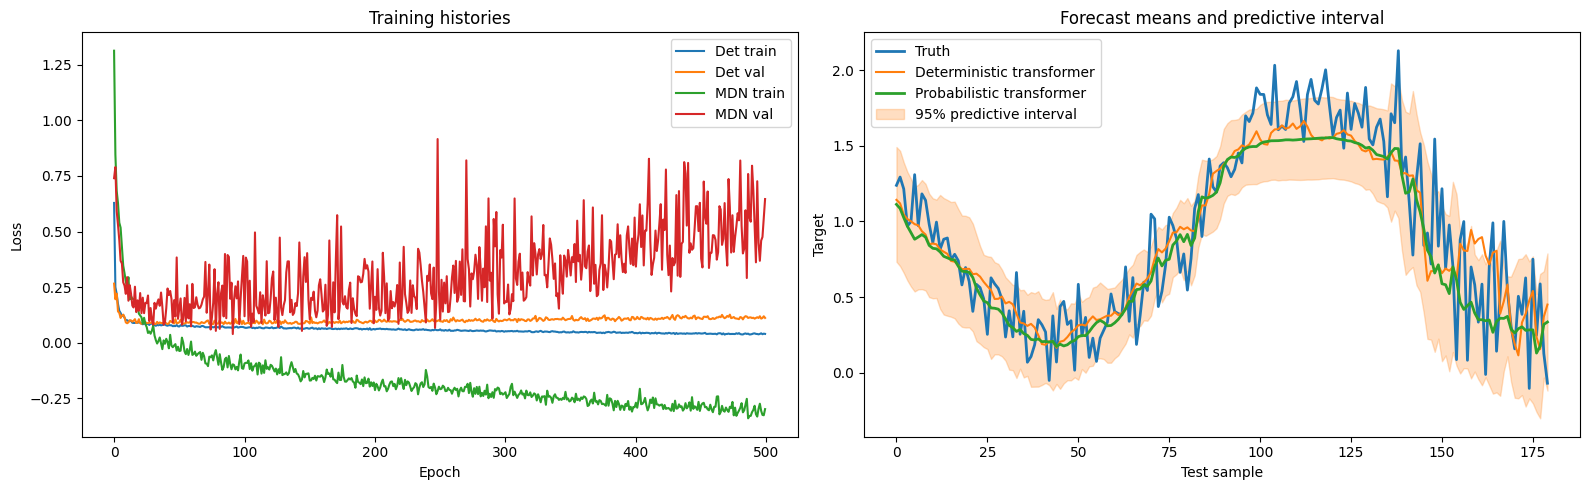

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(deterministic_model.history["loss"], label="Det train")
axes[0].plot(deterministic_model.history["val_loss"], label="Det val")
axes[0].plot(probabilistic_model.history["loss"], label="MDN train")
axes[0].plot(probabilistic_model.history["val_loss"], label="MDN val")
axes[0].set_title("Training histories")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

plot_count = 180
x_axis = np.arange(plot_count)
axes[1].plot(x_axis, y_test_real[:plot_count], label="Truth", linewidth=2)
axes[1].plot(x_axis, det_pred[:plot_count], label="Deterministic transformer")
axes[1].plot(
    x_axis, prob_pred[:plot_count], label="Probabilistic transformer", linewidth=2
)
axes[1].fill_between(
    x_axis,
    (prob_pred[:plot_count] - 1.96 * prob_std[:plot_count]).flatten(),
    (prob_pred[:plot_count] + 1.96 * prob_std[:plot_count]).flatten(),
    color="tab:orange",
    alpha=0.25,
    label="95% predictive interval",
)
axes[1].set_title("Forecast means and predictive interval")
axes[1].set_xlabel("Test sample")
axes[1].set_ylabel("Target")
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
mean_mix_coeffs = prob_components["mix_coeffs"].mean(axis=0)
pd.DataFrame(
    {
        "Mixture component": np.arange(1, len(mean_mix_coeffs) + 1),
        "Average coefficient": mean_mix_coeffs,
    }
)

,Mixture component,Average coefficient
0,1,0.859183
1,2,0.103323
2,3,0.037493


## Interpretation

Use the deterministic transformer as a strong point-forecast baseline. Use the probabilistic transformer when you need uncertainty estimates for noisy or multi-regime forecasting tasks.

In practice, this notebook gives you the basic workflow for the new probabilistic forecasting system:

- point forecast baseline
- probabilistic forecast with MDN head
- uncertainty-aware scoring
- interval visualization

A natural next step is to repeat the same comparison for the RNN and then add a utility for combining multiple probabilistic forecasters into one ensemble uncertainty summary.